In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [9]:
df = pd.read_csv("superstore_sales.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully
Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category    

In [11]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

print("Order Date converted successfully")

display(
    df[["Customer ID", "Order Date", "Sales"]].head()
)

Order Date converted successfully


,Customer ID,Order Date,Sales
0,CG-12520,2017-11-08,261.9600
1,CG-12520,2017-11-08,731.9400
2,DV-13045,2017-06-12,14.6200
3,SO-20335,2016-10-11,957.5775
4,SO-20335,2016-10-11,22.3680


In [12]:
customer_metrics = df.groupby("Customer ID").agg(
    Total_Sales=("Sales", "sum"),
    Total_Orders=("Order ID", "nunique"),
    Last_Order_Date=("Order Date", "max"),
    First_Order_Date=("Order Date", "min")
).reset_index()

customer_metrics["Average_Order_Value"] = (
    customer_metrics["Total_Sales"] /
    customer_metrics["Total_Orders"]
)

customer_metrics["Customer_Lifetime_Days"] = (
    customer_metrics["Last_Order_Date"] -
    customer_metrics["First_Order_Date"]
).dt.days

print("Customer-level metrics created")

display(customer_metrics.head())

Customer-level metrics created


,Customer ID,Total_Sales,Total_Orders,Last_Order_Date,First_Order_Date,Average_Order_Value,Customer_Lifetime_Days
0,AA-10315,5563.560,5,2018-06-29,2015-03-31,1112.712000,1186
1,AA-10375,1056.390,9,2018-12-11,2015-04-21,117.376667,1330
2,AA-10480,1790.512,4,2018-04-15,2015-05-04,447.628000,1077
3,AA-10645,5086.935,6,2018-11-05,2015-06-22,847.822500,1232
4,AB-10015,886.156,3,2017-11-10,2015-02-18,295.385333,996


In [13]:
customer_metrics["Customer_Lifetime_Days"] = (
    customer_metrics["Customer_Lifetime_Days"]
    .clip(lower=1)
)

print("Customer lifetime days corrected")

display(
    customer_metrics[
        [
            "Customer ID",
            "Total_Sales",
            "Total_Orders",
            "Average_Order_Value",
            "Customer_Lifetime_Days"
        ]
    ].head()
)

Customer lifetime days corrected


,Customer ID,Total_Sales,Total_Orders,Average_Order_Value,Customer_Lifetime_Days
0,AA-10315,5563.560,5,1112.712000,1186
1,AA-10375,1056.390,9,117.376667,1330
2,AA-10480,1790.512,4,447.628000,1077
3,AA-10645,5086.935,6,847.822500,1232
4,AB-10015,886.156,3,295.385333,996


In [14]:
reference_date = customer_metrics["Last_Order_Date"].max()

customer_metrics["Recency_Days"] = (
    reference_date -
    customer_metrics["Last_Order_Date"]
).dt.days

print("Reference Date:", reference_date)

display(
    customer_metrics[
        [
            "Customer ID",
            "Last_Order_Date",
            "Recency_Days"
        ]
    ].head(10)
)

Reference Date: 2018-12-30 00:00:00


,Customer ID,Last_Order_Date,Recency_Days
0,AA-10315,2018-06-29,184
1,AA-10375,2018-12-11,19
2,AA-10480,2018-04-15,259
3,AA-10645,2018-11-05,55
4,AB-10015,2017-11-10,415
5,AB-10060,2018-11-06,54
6,AB-10105,2018-11-19,41
7,AB-10150,2018-11-19,41
8,AB-10165,2018-12-05,25
9,AB-10255,2018-07-17,166


In [15]:
customer_metrics["Purchase_Frequency"] = (
    customer_metrics["Total_Orders"] /
    np.maximum(
        customer_metrics["Customer_Lifetime_Days"] / 365,
        1
    )
)

print("Purchase frequency calculated")

display(
    customer_metrics[
        [
            "Customer ID",
            "Total_Orders",
            "Customer_Lifetime_Days",
            "Purchase_Frequency"
        ]
    ].head(10)
)

Purchase frequency calculated


,Customer ID,Total_Orders,Customer_Lifetime_Days,Purchase_Frequency
0,AA-10315,5,1186,1.538786
1,AA-10375,9,1330,2.469925
2,AA-10480,4,1077,1.355617
3,AA-10645,6,1232,1.777597
4,AB-10015,3,996,1.099398
5,AB-10060,8,779,3.748395
6,AB-10105,10,1065,3.427230
7,AB-10150,5,1355,1.346863
8,AB-10165,8,1115,2.618834
9,AB-10255,9,1091,3.010999


In [16]:
expected_lifetime_years = 3

customer_metrics["Estimated_CLV"] = (
    customer_metrics["Average_Order_Value"]
    * customer_metrics["Purchase_Frequency"]
    * expected_lifetime_years
)

print("Estimated CLV calculated")

display(
    customer_metrics[
        [
            "Customer ID",
            "Total_Sales",
            "Average_Order_Value",
            "Purchase_Frequency",
            "Estimated_CLV"
        ]
    ]
    .sort_values("Estimated_CLV", ascending=False)
    .head(10)
)

Estimated CLV calculated


,Customer ID,Total_Sales,Average_Order_Value,Purchase_Frequency,Estimated_CLV
621,RB-19360,15117.339,2519.556500,4.040590,30541.487463
741,TC-20980,19052.218,3810.443600,2.433333,27816.238280
146,CJ-12010,11164.974,1395.621750,6.199575,25956.786688
131,CC-12370,12129.072,2425.814400,3.360958,24459.178343
700,SM-20320,25043.050,5008.610000,1.399540,21029.248275
588,PF-19120,9062.864,2265.716000,2.914172,19808.056048
6,AB-10105,14473.571,1447.357100,3.427230,14881.277225
104,BS-11365,10501.653,2100.330600,2.345758,14780.604158
669,SC-20095,14142.334,1571.370444,3.075843,14499.864916
90,BM-11140,11789.630,2947.407500,1.618625,14312.244845


In [17]:
customer_metrics["Risk_Score"] = (
    customer_metrics["Recency_Days"] * 0.5
    - customer_metrics["Purchase_Frequency"] * 10
    - customer_metrics["Estimated_CLV"] * 0.0002
)

print("Customer risk score calculated")

display(
    customer_metrics[
        [
            "Customer ID",
            "Recency_Days",
            "Purchase_Frequency",
            "Estimated_CLV",
            "Risk_Score"
        ]
    ]
    .sort_values("Risk_Score", ascending=False)
    .head(10)
)

Customer risk score calculated


,Customer ID,Recency_Days,Purchase_Frequency,Estimated_CLV,Risk_Score
552,NB-18580,1165,2.000000,821.616000,562.335677
309,GR-14560,1135,2.000000,3853.140000,546.729372
637,RE-19405,1097,1.000000,145.080000,538.470984
785,VT-21700,999,2.000000,5209.788000,478.458042
163,CM-12715,1034,4.000000,11953.357200,474.609329
587,PC-19000,881,1.517672,2416.485156,424.839988
231,DP-13165,811,2.000000,3175.848000,384.864830
23,AG-10525,844,3.696203,4033.586354,384.231257
588,PF-19120,834,2.914172,19808.056048,383.896672
137,CC-12685,798,2.512909,5379.097978,372.795093


In [18]:
customer_metrics["Risk_Level"] = pd.qcut(
    customer_metrics["Risk_Score"],
    q=3,
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],
    duplicates="drop"
)

print("Risk categories created")

display(
    customer_metrics[
        [
            "Customer ID",
            "Risk_Score",
            "Risk_Level"
        ]
    ].head(10)
)

Risk categories created


,Customer ID,Risk_Score,Risk_Level
0,AA-10315,75.584806,High Risk
1,AA-10375,-15.373195,Low Risk
2,AA-10480,115.579738,High Risk
3,AA-10645,8.819774,Medium Risk
4,AB-10015,196.311177,High Risk
5,AB-10060,-12.664289,Low Risk
6,AB-10105,-16.748556,Low Risk
7,AB-10150,6.875122,Medium Risk
8,AB-10165,-13.907113,Low Risk
9,AB-10255,52.706432,High Risk


In [19]:
risk_distribution = (
    customer_metrics["Risk_Level"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

print("Customer Risk Distribution")
print("--------------------------")

display(risk_distribution)

Customer Risk Distribution
--------------------------


Risk_Level
Low Risk       265
Medium Risk    264
High Risk      264
Name: count, dtype: int64

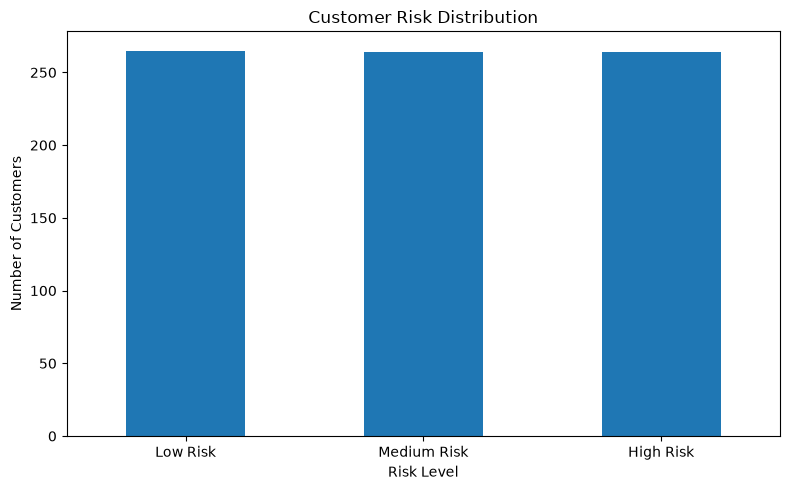

In [20]:
plt.figure(figsize=(8, 5))

risk_distribution.plot(kind="bar")

plt.title("Customer Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [21]:
high_risk_customers = (
    customer_metrics[
        customer_metrics["Risk_Level"] == "High Risk"
    ]
    .sort_values("Risk_Score", ascending=False)
)

print("Top High-Risk Customers")
print("-----------------------")

display(
    high_risk_customers[
        [
            "Customer ID",
            "Total_Sales",
            "Total_Orders",
            "Recency_Days",
            "Purchase_Frequency",
            "Estimated_CLV",
            "Risk_Score",
            "Risk_Level"
        ]
    ].head(10)
)

Top High-Risk Customers
-----------------------


,Customer ID,Total_Sales,Total_Orders,Recency_Days,Purchase_Frequency,Estimated_CLV,Risk_Score,Risk_Level
552,NB-18580,273.8720,2,1165,2.000000,821.616000,562.335677,High Risk
309,GR-14560,1284.3800,2,1135,2.000000,3853.140000,546.729372,High Risk
637,RE-19405,48.3600,1,1097,1.000000,145.080000,538.470984,High Risk
785,VT-21700,1736.5960,2,999,2.000000,5209.788000,478.458042,High Risk
163,CM-12715,3984.4524,4,1034,4.000000,11953.357200,474.609329,High Risk
587,PC-19000,1061.4880,2,881,1.517672,2416.485156,424.839988,High Risk
231,DP-13165,1058.6160,2,811,2.000000,3175.848000,384.864830,High Risk
23,AG-10525,1455.0380,4,844,3.696203,4033.586354,384.231257,High Risk
588,PF-19120,9062.8640,4,834,2.914172,19808.056048,383.896672,High Risk
137,CC-12685,2854.1150,4,798,2.512909,5379.097978,372.795093,High Risk


In [22]:
print("Predictive Customer Risk Recommendations")
print("-----------------------------------------")

print("""
1. High-Risk Customers
   - Prioritize customers with high risk scores.
   - Send personalized re-engagement offers.
   - Focus especially on high-CLV customers.

2. Medium-Risk Customers
   - Use targeted promotions and reminders.
   - Encourage repeat purchases.
   - Monitor changes in purchase frequency.

3. Low-Risk Customers
   - Maintain loyalty through rewards.
   - Provide personalized recommendations.
   - Encourage continued engagement.

4. Business Strategy
   - Combine recency, purchase frequency, and CLV.
   - Use risk scores to prioritize retention efforts.
   - Focus resources on customers with both high risk and high value.
""")

Predictive Customer Risk Recommendations
-----------------------------------------

1. High-Risk Customers
   - Prioritize customers with high risk scores.
   - Send personalized re-engagement offers.
   - Focus especially on high-CLV customers.

2. Medium-Risk Customers
   - Use targeted promotions and reminders.
   - Encourage repeat purchases.
   - Monitor changes in purchase frequency.

3. Low-Risk Customers
   - Maintain loyalty through rewards.
   - Provide personalized recommendations.
   - Encourage continued engagement.

4. Business Strategy
   - Combine recency, purchase frequency, and CLV.
   - Use risk scores to prioritize retention efforts.
   - Focus resources on customers with both high risk and high value.



In [23]:
customer_metrics.to_csv(
    "day41_customer_risk_scores.csv",
    index=False
)

print("Day 41 customer risk analysis saved successfully.")
print("File: day41_customer_risk_scores.csv")

Day 41 customer risk analysis saved successfully.
File: day41_customer_risk_scores.csv


In [24]:
# Step 17: Load final customer risk scores

risk_scores = pd.read_csv("day41_customer_risk_scores.csv")

print("Risk score dataset shape:", risk_scores.shape)

risk_scores.head(10)

Risk score dataset shape: (793, 12)


,Customer ID,Total_Sales,Total_Orders,Last_Order_Date,First_Order_Date,Average_Order_Value,Customer_Lifetime_Days,Recency_Days,Purchase_Frequency,Estimated_CLV,Risk_Score,Risk_Level
0,AA-10315,5563.560,5,2018-06-29,2015-03-31,1112.712000,1186,184,1.538786,5136.676391,75.584806,High Risk
1,AA-10375,1056.390,9,2018-12-11,2015-04-21,117.376667,1330,19,2.469925,869.734624,-15.373195,Low Risk
2,AA-10480,1790.512,4,2018-04-15,2015-05-04,447.628000,1077,259,1.355617,1820.436992,115.579738,High Risk
3,AA-10645,5086.935,6,2018-11-05,2015-06-22,847.822500,1232,55,1.777597,4521.261222,8.819774,Medium Risk
4,AB-10015,886.156,3,2017-11-10,2015-02-18,295.385333,996,415,1.099398,974.237771,196.311177,High Risk
5,AB-10060,7755.620,8,2018-11-06,2016-09-18,969.452500,779,54,3.748395,10901.673813,-12.664289,Low Risk
6,AB-10105,14473.571,10,2018-11-19,2015-12-20,1447.357100,1065,41,3.427230,14881.277225,-16.748556,Low Risk
7,AB-10150,966.710,5,2018-11-19,2015-03-05,193.342000,1355,41,1.346863,781.215830,6.875122,Medium Risk
8,AB-10165,1113.838,8,2018-12-05,2015-11-16,139.229750,1115,25,2.618834,1093.858843,-13.907113,Low Risk
9,AB-10255,914.532,9,2018-07-17,2015-07-22,101.614667,1091,166,3.010999,917.885005,52.706432,High Risk


In [25]:
# Step 18: Count customers in each risk category

risk_counts = risk_scores["Risk_Level"].value_counts()

print("Customer Risk Distribution")
print("--------------------------")
print(risk_counts)

Customer Risk Distribution
--------------------------
Risk_Level
Low Risk       265
High Risk      264
Medium Risk    264
Name: count, dtype: int64


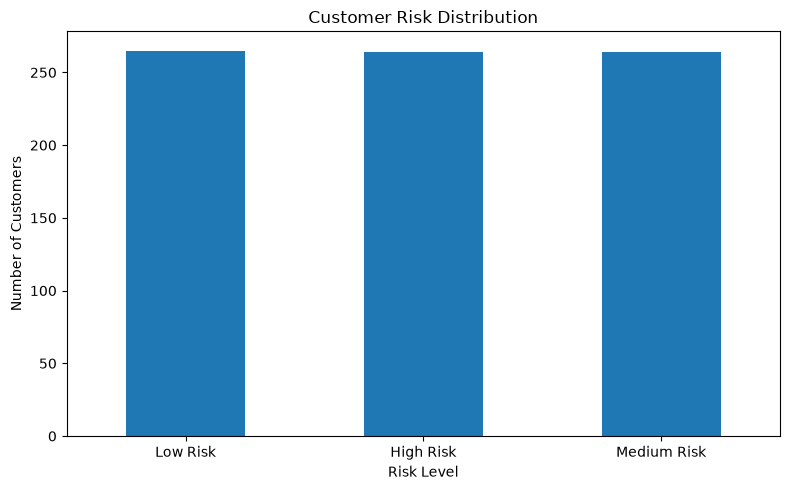

In [26]:
# Step 19: Visualize customer risk distribution

plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("Customer Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [27]:
# Step 20: Top 10 highest-risk customers

top_risk_customers = risk_scores.sort_values(
    by="Risk_Score",
    ascending=False
).head(10)

print("Top 10 Highest-Risk Customers")
print("-----------------------------")

top_risk_customers[
    [
        "Customer ID",
        "Risk_Score",
        "Risk_Level",
        "Recency_Days",
        "Purchase_Frequency",
        "Estimated_CLV"
    ]
]

Top 10 Highest-Risk Customers
-----------------------------


,Customer ID,Risk_Score,Risk_Level,Recency_Days,Purchase_Frequency,Estimated_CLV
552,NB-18580,562.335677,High Risk,1165,2.000000,821.616000
309,GR-14560,546.729372,High Risk,1135,2.000000,3853.140000
637,RE-19405,538.470984,High Risk,1097,1.000000,145.080000
785,VT-21700,478.458042,High Risk,999,2.000000,5209.788000
163,CM-12715,474.609329,High Risk,1034,4.000000,11953.357200
587,PC-19000,424.839988,High Risk,881,1.517672,2416.485156
231,DP-13165,384.864830,High Risk,811,2.000000,3175.848000
23,AG-10525,384.231257,High Risk,844,3.696203,4033.586354
588,PF-19120,383.896672,High Risk,834,2.914172,19808.056048
137,CC-12685,372.795093,High Risk,798,2.512909,5379.097978


In [28]:
# Step 21: High-risk customers with high CLV

high_risk_high_clv = risk_scores[
    (risk_scores["Risk_Level"] == "High Risk")
].sort_values(
    by="Estimated_CLV",
    ascending=False
).head(10)

print("High-Risk Customers with Highest CLV")
print("-------------------------------------")

high_risk_high_clv[
    [
        "Customer ID",
        "Risk_Score",
        "Risk_Level",
        "Recency_Days",
        "Purchase_Frequency",
        "Estimated_CLV"
    ]
]

High-Risk Customers with Highest CLV
-------------------------------------


,Customer ID,Risk_Score,Risk_Level,Recency_Days,Purchase_Frequency,Estimated_CLV
741,TC-20980,169.603419,High Risk,399,2.433333,27816.238280
588,PF-19120,383.896672,High Risk,834,2.914172,19808.056048
104,BS-11365,252.586296,High Risk,558,2.345758,14780.604158
669,SC-20095,140.841600,High Risk,349,3.075843,14499.864916
90,BM-11140,134.451298,High Risk,307,1.618625,14312.244845
422,KD-16270,211.646238,High Risk,484,2.760968,13720.396384
163,CM-12715,474.609329,High Risk,1034,4.000000,11953.357200
643,RH-19510,198.688053,High Risk,467,3.254086,11355.426597
152,CL-12565,100.505984,High Risk,284,3.935310,10704.580296
776,VD-21670,255.340341,High Risk,581,3.303167,10639.921765


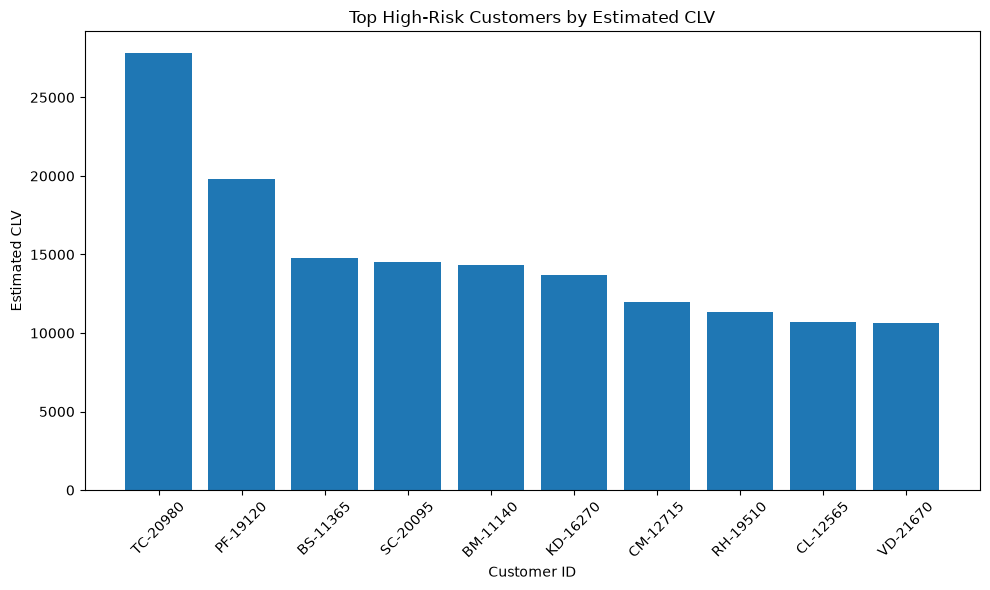

In [29]:
# Step 22: High-risk customers by Estimated CLV

plt.figure(figsize=(10, 6))

plt.bar(
    high_risk_high_clv["Customer ID"],
    high_risk_high_clv["Estimated_CLV"]
)

plt.title("Top High-Risk Customers by Estimated CLV")
plt.xlabel("Customer ID")
plt.ylabel("Estimated CLV")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Step 23: Create retention priority score

risk_scores["Retention_Priority"] = (
    risk_scores["Risk_Score"] * risk_scores["Estimated_CLV"]
)

priority_customers = risk_scores.sort_values(
    by="Retention_Priority",
    ascending=False
).head(10)

print("Top 10 Customers for Retention Priority")
print("----------------------------------------")

priority_customers[
    [
        "Customer ID",
        "Risk_Score",
        "Risk_Level",
        "Estimated_CLV",
        "Retention_Priority"
    ]
]

Top 10 Customers for Retention Priority
----------------------------------------


,Customer ID,Risk_Score,Risk_Level,Estimated_CLV,Retention_Priority
588,PF-19120,383.896672,High Risk,19808.056048,7.604247e+06
163,CM-12715,474.609329,High Risk,11953.357200,5.673175e+06
741,TC-20980,169.603419,High Risk,27816.238280,4.717729e+06
104,BS-11365,252.586296,High Risk,14780.604158,3.733378e+06
422,KD-16270,211.646238,High Risk,13720.396384,2.903870e+06
776,VD-21670,255.340341,High Risk,10639.921765,2.716801e+06
785,VT-21700,478.458042,High Risk,5209.788000,2.492665e+06
693,SH-20635,360.742165,High Risk,6289.176000,2.268771e+06
643,RH-19510,198.688053,High Risk,11355.426597,2.256188e+06
667,SC-20020,359.277526,High Risk,5958.649097,2.140809e+06


In [32]:
# Load the completed Day 41 customer risk data

import pandas as pd

customer_risk = pd.read_csv("day41_customer_risk_scores.csv")

customer_risk.head()

,Customer ID,Total_Sales,Total_Orders,Last_Order_Date,First_Order_Date,Average_Order_Value,Customer_Lifetime_Days,Recency_Days,Purchase_Frequency,Estimated_CLV,Risk_Score,Risk_Level
0,AA-10315,5563.560,5,2018-06-29,2015-03-31,1112.712000,1186,184,1.538786,5136.676391,75.584806,High Risk
1,AA-10375,1056.390,9,2018-12-11,2015-04-21,117.376667,1330,19,2.469925,869.734624,-15.373195,Low Risk
2,AA-10480,1790.512,4,2018-04-15,2015-05-04,447.628000,1077,259,1.355617,1820.436992,115.579738,High Risk
3,AA-10645,5086.935,6,2018-11-05,2015-06-22,847.822500,1232,55,1.777597,4521.261222,8.819774,Medium Risk
4,AB-10015,886.156,3,2017-11-10,2015-02-18,295.385333,996,415,1.099398,974.237771,196.311177,High Risk


In [33]:
# Create retention strategy recommendations

def retention_strategy(row):
    if row["Risk_Level"] == "High Risk" and row["Estimated_CLV"] >= 10000:
        return "Immediate Retention Campaign"
    elif row["Risk_Level"] == "High Risk":
        return "Targeted Re-engagement"
    elif row["Risk_Level"] == "Medium Risk":
        return "Engagement Campaign"
    else:
        return "Maintain Relationship"


customer_risk["Retention_Strategy"] = customer_risk.apply(
    retention_strategy,
    axis=1
)

customer_risk[
    [
        "Customer ID",
        "Risk_Level",
        "Estimated_CLV",
        "Retention_Strategy"
    ]
].head(10)

,Customer ID,Risk_Level,Estimated_CLV,Retention_Strategy
0,AA-10315,High Risk,5136.676391,Targeted Re-engagement
1,AA-10375,Low Risk,869.734624,Maintain Relationship
2,AA-10480,High Risk,1820.436992,Targeted Re-engagement
3,AA-10645,Medium Risk,4521.261222,Engagement Campaign
4,AB-10015,High Risk,974.237771,Targeted Re-engagement
5,AB-10060,Low Risk,10901.673813,Maintain Relationship
6,AB-10105,Low Risk,14881.277225,Maintain Relationship
7,AB-10150,Medium Risk,781.215830,Engagement Campaign
8,AB-10165,Low Risk,1093.858843,Maintain Relationship
9,AB-10255,High Risk,917.885005,Targeted Re-engagement


In [34]:
# Count customers in each retention strategy

strategy_counts = customer_risk["Retention_Strategy"].value_counts()

print("Retention Strategy Distribution")
print("--------------------------------")
print(strategy_counts)

Retention Strategy Distribution
--------------------------------
Retention_Strategy
Maintain Relationship           265
Engagement Campaign             264
Targeted Re-engagement          254
Immediate Retention Campaign     10
Name: count, dtype: int64


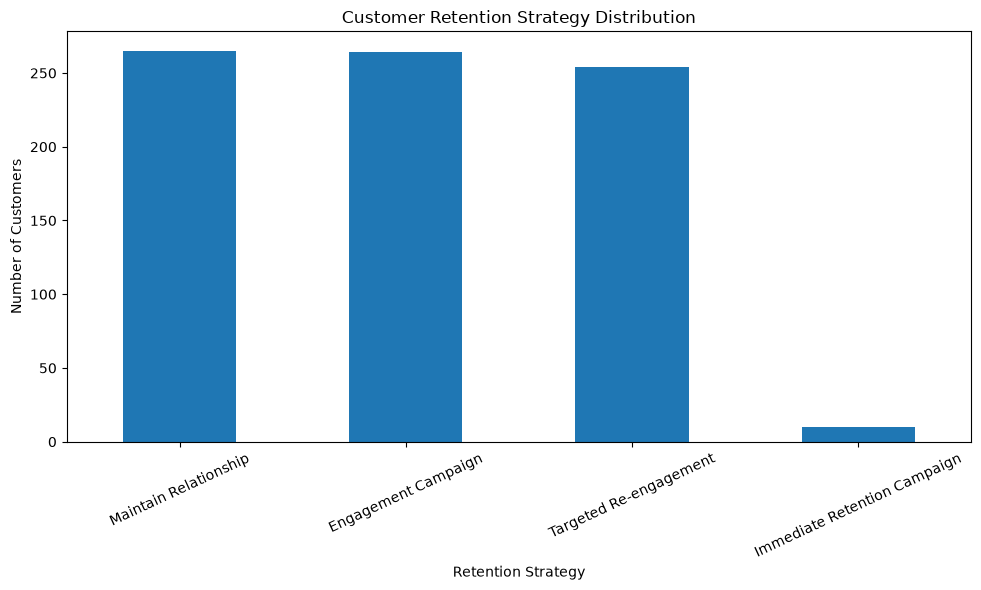

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

strategy_counts.plot(kind="bar")

plt.title("Customer Retention Strategy Distribution")
plt.xlabel("Retention Strategy")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.tight_layout()

plt.show()

In [36]:
# Save the final customer risk analysis

customer_risk.to_csv(
    "day41_customer_risk_final.csv",
    index=False
)

print("Day 41 final customer risk analysis saved successfully.")
print("File: day41_customer_risk_final.csv")

Day 41 final customer risk analysis saved successfully.
File: day41_customer_risk_final.csv


## Business Insights and Recommendations

### Key Findings

1. The customer risk system identified customers as Low, Medium, and High Risk based on behavioral signals such as recency, purchase frequency, and estimated CLV.

2. The risk distribution contains:
   - 265 Low Risk customers
   - 264 Medium Risk customers
   - 264 High Risk customers

3. The retention strategy analysis identified:
   - 265 customers → Maintain Relationship
   - 264 customers → Engagement Campaign
   - 254 customers → Targeted Re-engagement
   - 10 customers → Immediate Retention Campaign

4. The 10 customers classified for Immediate Retention Campaign represent the highest-priority segment because they combine high churn risk with high estimated customer lifetime value.

### Business Recommendations

- Prioritize immediate retention campaigns for high-risk, high-value customers.
- Use targeted re-engagement campaigns for other high-risk customers.
- Use engagement campaigns to prevent medium-risk customers from becoming high risk.
- Continue regular relationship-building activities for low-risk customers.
- Monitor customer risk scores regularly so retention teams can act before valuable customers are lost.

### Business Impact

This predictive customer risk system helps businesses move from reactive churn management to proactive customer retention. By combining customer behavior, risk scoring, and estimated CLV, businesses can prioritize retention resources toward customers where intervention can create the greatest value.